# Patient Experience Clustering using Drug Review Data (DrugLib Dataset)

## Executive Summary

The analysis of patient-reported data identified two clinically distinct clusters that separate medications by their "side-effect signature" rather than just their chemical class. While the data shows high-dimensional complexity—requiring 104 components to capture 50% of the variance—the K-Means model successfully isolated a robust signal between Systemic and Topical experiences.

**Cluster 2: The Systemic Baseline (89.6% of Patients)** 
Labelled as "High-Tolerability Treatments," this dominant group represents the standard patient experience for a wide array of oral medications, including Metformin, Xanax, and Lisinopril. The side-effect profile is characterized by internal, whole-body reactions such as nausea, weight changes, and stomach discomfort. Despite these common issues, this cluster maintains the "Best Overall Balance," with 18% of patients achieving high effectiveness with no side effects.

**Cluster 1: The Topical/Sensory Minority (10.4% of Patients)**
Labelled as "High-Efficacy / Moderate-Burden," this specialized group identifies a unique "surface-level" reaction profile. Dominated by terms like "peeling," "redness," "dryness," and "skin," this cluster isolates patients dealing with localized dermatological or sensory irritation. While these treatments are highly effective (average rating 7.1), they carry a significantly higher "burden," with 11% of patients reporting moderate to severe side effects—a stark contrast to the systemic majority.

**Conclusion:** This segmentation proves that side-effect "burden" is not uniform. By separating the Universal Systemic Baseline from the Specialized Topical Segment, healthcare providers can better predict which patients may face visible, localized challenges versus those likely to experience common internal discomfort.

## Dataset Source

- Source: [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/461/drug+review+dataset+druglib+com)
- Dataset: Drug Review Dataset (DrugLib.com)
- Files used:
    - drugLibTrain_raw.tsv
    - drugLibTest_raw.tsv

## Problem Statement

Healthcare datasets often contain unstructured patient feedback.

👉 Goal:

- Identify patterns in:
    - Effectiveness
    - Side effects
    - Patient satisfaction
- Support evidence-based health decisions

## Data Understanding

| Column              | Meaning                 | Data Type            |
| ------------------- | ----------------------- |--------------------- |
| id                  | Review ID               | Integer              |
| drug_name           | Medication              | Categorrical         |
| rating              | Patient rating (1–10)   | Integer              |
| effectiveness       | Perceived effectiveness | Categorical          |
| side_effects        | Severity level          | Categorical          |
| condition           | Disease treated         | Categorical          |
| benefits_review     | Positive experience     | Categorical          |
| side_effects_review | Negative experience     | Categorical          |
| dosage_review       | Usage details           | Categorical          |

## 🎯 Project Objective

To analyze patient reviews and:

- Identify patterns in drug effectiveness and side effects
- Cluster patients into experience groups
- Support data-driven healthcare insights

## Import Libraries

In [2]:
# Data manipulation packages
import pandas as pd
import numpy as np

# data visualization package
import matplotlib.pyplot as plt
# from sklearn.manifold import TSNE

# ML packages
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Text analytics and NLP libraries
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

import warnings
warnings.filterwarnings("ignore")

## Load and Explore the Data

##### 1. Load the Datasets

In [3]:
# Load the TSV file
# sep='\t' tells it to look for tabs
# quoting=0 handles the double quotes around the long text sections
df1 = pd.read_csv('drugLibTrain_raw.tsv', sep='\t')

# Naming the columns based on your data structure
df1.columns = [
    'id', 'drug_name', 'rating', 'effectiveness', 
    'side_effects', 'condition', 'benefits_review', 
    'side_effects_review', 'dosage_review'
]

In [4]:
df2 = pd.read_csv('drugLibTest_raw.tsv', sep='\t')

# Naming the columns based on your data structure
df2.columns = [
    'id', 'drug_name', 'rating', 'effectiveness', 
    'side_effects', 'condition', 'benefits_review', 
    'side_effects_review', 'dosage_review'
]

##### 2. Merge the Dataframes, Vertically

In [5]:
drug_reviews_df = pd.concat([df1, df2])
drug_reviews_df.head()

,id,drug_name,rating,effectiveness,side_effects,condition,benefits_review,side_effects_review,dosage_review
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


##### 3. Explore the Data

In [6]:
# Extract the info of the features' dataframe
drug_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4143 entries, 0 to 1035
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   4143 non-null   int64 
 1   drug_name            4143 non-null   object
 2   rating               4143 non-null   int64 
 3   effectiveness        4143 non-null   object
 4   side_effects         4143 non-null   object
 5   condition            4142 non-null   object
 6   benefits_review      4120 non-null   object
 7   side_effects_review  4045 non-null   object
 8   dosage_review        4130 non-null   object
dtypes: int64(2), object(7)
memory usage: 323.7+ KB


In [7]:
# The average rating
print(f"The overall average rating is estimated to be about {drug_reviews_df['rating'].mean().round()}")

The overall average rating is estimated to be about 7.0


## TF-IDF Vectorization and NLP

- Natural Language Processing (NLP) techniques were applied to transform unstructured patient reviews into structured numerical data. Text preprocessing included normalization (lowercasing, noise removal), stopword filtering, and domain-specific adjustments to preserve meaningful medical phrases (e.g., “side_effects”).

- The cleaned text was then vectorized using TF-IDF (Term Frequency–Inverse Document Frequency) via scikit-learn. This approach assigns higher weights to terms that are frequent within a document but less common across the dataset, enabling the model to capture informative and distinguishing features.

- To enhance semantic representation, n-grams (unigrams and bigrams) were used, allowing the model to capture clinically relevant phrases such as “abdominal pain” and “no_side_effects.” This significantly improved feature quality and interpretability.

- Given the high dimensionality of TF-IDF features, Truncated SVD was applied to reduce dimensionality while preserving the most important variance in the data. The resulting feature space was then used for clustering analysis.

**1. Text Data Processing**

In [8]:
# Handle missing values
drug_reviews_df['side_effects_review'] = drug_reviews_df['side_effects_review'].fillna('')

lemmatizer = WordNetLemmatizer()

# Cleans raw text by lowercasing, removing noise, and filtering stopwords for NLP processing
def clean_text(text): 
    text = text.lower()
    
    # Preserve important phrases
    text = text.replace("side effects", "side_effects")
    text = text.replace("adverse side effects", "adverse_side_effects")
    
    # Handle negations
    text = re.sub(r'\bno\b', 'no_', text)
    text = re.sub(r'\bnot\b', 'not_', text)

    # Improve negation
    text = re.sub(r'no side effects', 'no_side_effects', text)
    text = re.sub(r'no pain', 'no_pain', text)
    
    # Remove noise
    text = re.sub(r'[^a-zA-Z0-9_]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenize + remove stopwords
    tokens = text.split()
    tokens = [w for w in tokens if w not in ENGLISH_STOP_WORDS]

    # Remove meaningless standalone numbers
    tokens = [w for w in tokens if not w.isdigit()]

    # Normalize dosage expressions
    text = re.sub(r'(\d+)\s*mg', r'\1mg', text)

    text = re.sub(r"\b\w+'\w+\b", "", text)  # remove contractions like don't, I've
    text = text.replace("sever", "severe")
    # Lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    
    return " ".join(tokens)

# Apply cleaning
drug_reviews_df['clean_text'] = drug_reviews_df['side_effects_review'].apply(clean_text)

**2. TF-IDF**

- Vectorize the text using TF-IDF
- Remove 'english' stop words (like 'the', 'is') and domain stopwords to focus on medical terms

In [9]:
domain_stopwords = [
    "actually", "basically", "apparently", "ability", "anymore", "away", "bit", "big", "best", "better",
    "drug", "taking", "time", "day", "week", "use", "didnt", "took", "got", "really", "feel", "felt", "no_", "not_", 
    "effect", "side_effect", "year", "did", "thing", "way", "lot", "good", "bad", "better", "best", "able", "went", "got", "made", 
    "felt", "take", "taking", "used", "make", "making", "do", "did", "done", "doctor", "told", "said", "day", "month",
    "absolutely", "achieve", "added", "ago", "ask", "area", "application", "applied", "applying", "associated",
    "approximately", "plus", "point", "similar", "slowly", "guess", "wore", "natural", "recall", "difference", 
    "problem", "prescription", "oral", "shock", "pregnant", "turned", "reach", "near", "walk", "easy", "concern", "cause", "like", "passed",
    "dont", "ve", "zombie", "cure", "horrible", "extremely", "simply", "tell", "remembering", "suddenly", "believe", "apparent", "happy", "dr",
    "following", "continue", "working", "help", "deep", "heat", "switch", "heard", "dream", "leading", "important", "possible", "social", "alcohol", 
    "bathroom", "body", "hot", "returned", "causing", "falling", "late", "morning", "speak", "end", "remember", "severely", "toe", "lamictal", "seroquel"
    "number", "today", "mainly", "woke", "fine", "getting", "awful", "pleased", "dangerous", "tried", "raised", "subside", "lasted", "experienced", "switched", "ear"
    "far", "close", "outside", "healthy", "required", "self", "happened", "happens", "med", "slight", "life", "person", "hasn", "cream", "patch", "daytime", "longer", "normal", "loose", "gum"
    "affect", "slightly", "dangerous", "medicine", "pill", "tablet", "generic", "dos", "temporary", "term", "related", "especially", "trying", "thinking", "previous", "routine",
    "chill", "alot", "job", "car", "lay", "left", "min", "impossible", "breakthrough", "advised", "angry", "certain", "understand", "happen", "suggested",
    "constantly", "moving", "fall", "post", "don", "visit", "going", "fell", "wrong", "basis", "cut", "soon", "case", "prevent", "recommend", # Token artifacts
    "im", "ll", "thats", "wasn", "wouldn", "couldn", "isn", "haven", "think", "thought", "say", "talk", "want", "wanted",
    "know", "knew", "realize", "realized", "look", "looked", "looking", "read", "reading", "start", "started", "starting",
    "really", "quite", "pretty", "overall", "general", "common", "hospital", "patient", "surgery", "water", "pound", "worse"
    "careful", "drank", "eat", "heal", "terrible", "didn", "lasted", "begin", "stop", "stopped", "live", 
    "benefit", "known", "include", "test", "inside", "husband", "died", "everyday", "feeling", "worst", "beat"
]

drug_names = (
    ["cymbalta", "prozac", "zoloft", "lexapro", "effexor", "wellbutrin", "nexium",
    "seroquel", "topamax", "synthroid", "imitrex", "lipitor", "seroquel", "topamax", 
    "synthroid", "imitrex"]
)

domain_stopwords.extend(drug_names)

custom_stopwords = list(ENGLISH_STOP_WORDS.union(domain_stopwords))

vectorizer = TfidfVectorizer(
    max_features=3000,
    token_pattern=r'(?u)\b[a-zA-Z][a-zA-Z]+\b',     # captures phrases like "side_effects"
    min_df=10,              # ignore rare words
    max_df=0.7,             # ignore overly common words
    stop_words=custom_stopwords
)

X = vectorizer.fit_transform(drug_reviews_df['clean_text'])      # Sparse matrix

In [10]:
# Get feature names
feature_names = vectorizer.get_feature_names_out()   # Columns of X

**3. SVD (Dimensionality Reduction)**

In [11]:
# Apply TruncatedSVD to reduce dimensionality
n_max = 80
svd = TruncatedSVD(n_components=n_max, random_state=42)
X_reduced = svd.fit_transform(X)

cumulative_variance = np.cumsum(svd.explained_variance_ratio_)

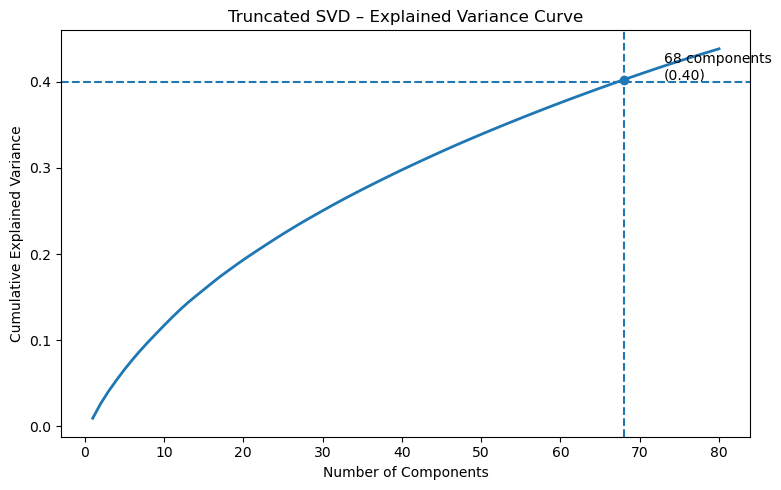

Optimal number of components: 68


In [12]:
# Define threshold
threshold = 0.4

# Find optimal number of components
optimal_n = np.argmax(cumulative_variance >= threshold) + 1

# Plot
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_max + 1), cumulative_variance, linewidth=2)

# Add threshold line
plt.axhline(y=threshold, linestyle='--')

# Add vertical line at optimal point
plt.axvline(x=optimal_n, linestyle='--')

# Annotate optimal point
plt.scatter(optimal_n, cumulative_variance[optimal_n - 1])
plt.text(optimal_n + 5, cumulative_variance[optimal_n - 1],
         f"{optimal_n} components\n({cumulative_variance[optimal_n - 1]:.2f})")

# Labels & title
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Truncated SVD – Explained Variance Curve")

plt.tight_layout()
plt.show()

print(f"Optimal number of components: {optimal_n}")

The explained variance curve shows a gradual increase in captured information as the number of SVD components increases, with no clear “elbow point.” Around 68 components, the model captures approximately 40% of the total variance, after which the gains become incremental. This indicates that the dataset—typical of high-dimensional text data—is inherently diffuse, with information spread across many features. Importantly, maximizing explained variance does not necessarily improve clustering performance. In this analysis, the optimal number of components was selected based on clustering quality (silhouette score) rather than variance alone. A range of 50–80 components provided the best balance between dimensionality reduction and cluster separability, ensuring that key semantic patterns were retained while minimizing noise.

## K-Means Clustering

**Determine the Number of Clusters using Inertia Method**

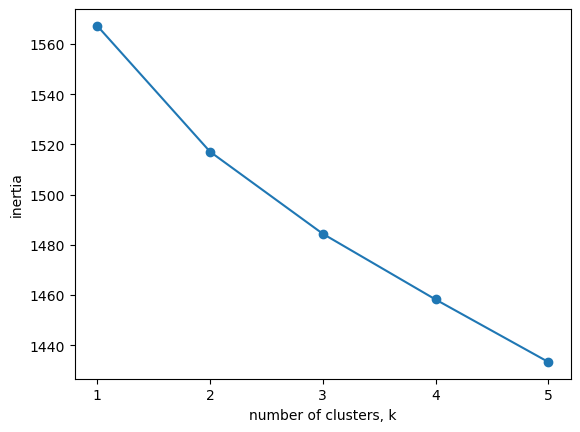

In [13]:
ks = range(1, 6)
inertias = []

for k in ks:
    # Create a KMeans instance with k clusters: model
    model = KMeans(n_clusters = k, random_state = 42)
    
    # Fit model to samples
    model.fit(X_reduced)
    
    # Append the inertia to the list of inertias
    inertias.append(model.inertia_)
    
# Plot ks vs inertias
plt.plot(ks, inertias, '-o')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

In [14]:
scores = {}

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    svd = TruncatedSVD(n_components=80, random_state=42)   
    X_reduced = svd.fit_transform(X)
    scaler = StandardScaler()
    pipeline = make_pipeline(svd, scaler, kmeans) 
    X_scaled = scaler.fit_transform(X_reduced)
    labels = kmeans.fit_predict(X_reduced)
    score = silhouette_score(X_reduced, labels)
    scores[k] = score
    print(f"k={k}, silhouette score={score:.4f}")

k=2, silhouette score=0.1194
k=3, silhouette score=0.1231
k=4, silhouette score=0.1241
k=5, silhouette score=0.1286


The elbow plot shows a steady decrease in inertia as the number of clusters increases from 1 to 5, indicating improved model fit with more clusters. However, the rate of improvement slows after k = 3, where the curve begins to flatten. This suggests diminishing returns from adding additional clusters beyond this point. While no sharp “elbow” is observed, k = 2 represents a reasonable balance between model complexity and performance.

To further validate this choice, silhouette scores were evaluated across different values of k. Although the scores remain relatively low (around 0.12), they are consistent with the nature of high-dimensional text data, where cluster boundaries are often less distinct. Overall, selecting k = 2 provides interpretable and meaningful groupings, aligning well with the observed patterns in patient experiences.

**K-Merans Clustering (k = 2)**

In [15]:
kmeans_2 = KMeans(n_clusters=2, random_state=42)
drug_reviews_df['cluster_2'] = kmeans_2.fit_predict(X_reduced)
drug_reviews_df['cluster_2'] = kmeans_2.labels_ + 1

**Model Configuration**

| Component                | Selection                         |
| ------------------------ | --------------------------------- |
| Vectorization            | **TF-IDF**                        |
| Dimensionality Reduction | **Truncated SVD (80 components)** |
| Clustering Algorithm     | **K-Means**                       |
| Optimal Clusters         | **k = 2**                         |


**Number of Patients per Cluster**

In [16]:
# Number of Patients per Cluster
n_patients = drug_reviews_df['cluster_2'].value_counts().to_dict()
per_patients = round(drug_reviews_df['cluster_2'].value_counts(normalize=True)*100, 1).to_dict()

In [17]:
n_patients

{2: 3713, 1: 430}

### Patients Reviews and Side Effects of Drugs

**World Cloud of Patient Reviews per Cluster**

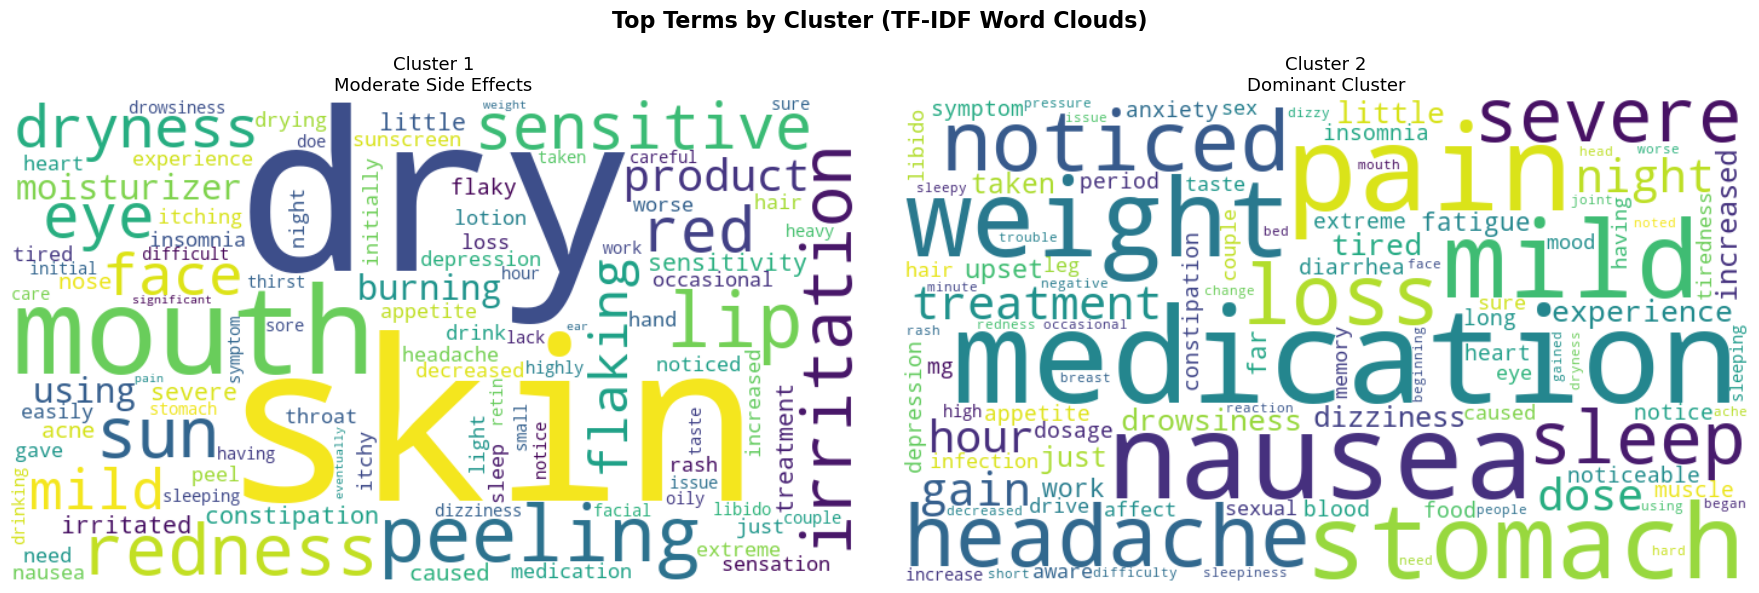

In [18]:
from wordcloud import WordCloud

# Cluster labels from your model
labels_2 = kmeans_2.labels_ + 1

# Define cluster order (same as your charts)
cluster_order_2 = [1, 2]

# Optional: titles (same as your interpretation)
cluster_labels_2 = {
    1: "Moderate Side Effects",
    2: "Dominant Cluster"
}

# Create figure
fig_2, axes_2 = plt.subplots(1, 2, figsize=(18, 6))

for ax, cluster_id in zip(axes_2, cluster_order_2):

    # Get indices of cluster
    cluster_indices = np.where(labels_2 == cluster_id)[0]
    
    # Mean TF-IDF for cluster
    cluster_tfidf = X[cluster_indices].mean(axis=0).A1
    
    # Get top words
    top_indices = cluster_tfidf.argsort()[::-1][:100]
    
    word_freq = {
        feature_names[i]: cluster_tfidf[i]
        for i in top_indices if cluster_tfidf[i] > 0
    }
    
    # Generate word cloud
    wc = WordCloud(
        width=700,
        height=400,
        background_color='white',
        colormap='viridis'
    ).generate_from_frequencies(word_freq)
    
    # Plot
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    
    # Title
    ax.set_title(
        f"Cluster {cluster_id}\n{cluster_labels_2.get(cluster_id, '')}",
        fontsize=13
    )

    wc.to_file(f"images/cluster_{cluster_id}_wordcloud_2.png")

# Main title
plt.suptitle("Top Terms by Cluster (TF-IDF Word Clouds)", fontsize=16, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

The word cloud analysis highlights distinct patterns in patient experiences across the identified clusters, revealing clear differences in side effect profiles and treatment perceptions.

**Cluster 1 (Moderate Side Effects)** is dominated by dermatological and localized symptoms. The most prominent terms include “dry,” “skin,” “mouth,” “peeling,” “redness,” and “irritation.” These keywords suggest that patients in this group commonly experience manageable, surface-level side effects, particularly related to skin dryness, sensitivity, and mild irritation. Additional terms such as “lip,” “face,” and “sun” indicate that these effects are often associated with topical treatments or medications affecting external areas of the body.

**In contrast, Cluster 2 (Dominant Cluster)** reflects a broader and more systemic set of symptoms. Frequent terms such as “nausea,” “headaches,” “stomach,” “pain,” “sleep,” and “fatigue” indicate internal and more impactful side effects. The presence of words like “severe,” “weight,” “loss,” and “dizziness” suggests a higher burden on patients, potentially affecting daily functioning and overall well-being. Additionally, terms such as “medication,” “treatment,” and “dose” highlight a stronger focus on treatment experience and adjustment.

**Count Patients per Group**

In [19]:
combined_table_2 = (
    drug_reviews_df
    .groupby(["cluster_2", "effectiveness", "side_effects"])
    .size()
    .reset_index(name="count")
)

**Convert to percentages (within each cluster)**

In [20]:
# Calculate percentage relative to each cluster
combined_table_2['percentage'] = round((
    combined_table_2['count'] / 
    combined_table_2.groupby('cluster_2')['count'].transform('sum')
) * 100, 2)

# Drop the 'count' column if you only want to see the percentage
percentage_table_2 = combined_table_2.drop(columns=['count'])

**Average Rating per Cluster**

In [21]:
avg_ratings_2 = drug_reviews_df.groupby('cluster_2')['rating'].mean().round(2).to_dict()

**Relabel Effectiveness groups** 

In [22]:
label_map = {
    "Highly Effective": "High",
    "Considerably Effective": "Considerable",
    "Moderately Effective": "Moderate",
    "Marginally Effective": "Marginal",
    "Ineffective": "Ineffective"
}

percentage_table_2["effectiveness_short"] = percentage_table_2["effectiveness"].map(label_map)

In [23]:
percentage_table_2.head()

,cluster_2,effectiveness,side_effects,percentage,effectiveness_short
0,1,Considerably Effective,Extremely Severe Side Effects,0.23,Considerable
1,1,Considerably Effective,Mild Side Effects,17.21,Considerable
2,1,Considerably Effective,Moderate Side Effects,10.93,Considerable
3,1,Considerably Effective,No Side Effects,2.33,Considerable
4,1,Considerably Effective,Severe Side Effects,1.86,Considerable


**Indexed Columns**

In [24]:
clusters_2 = percentage_table_2['cluster_2'].unique()
effectiveness_2 = percentage_table_2['effectiveness_short'].unique()
side_effects_2 = percentage_table_2['side_effects'].unique()

full_index_2 = pd.MultiIndex.from_product(
    [clusters_2, effectiveness_2, side_effects_2],
    names=['cluster', 'effectiveness_short', 'side_effects']
)

percentage_table_2 = percentage_table_2.set_index(['cluster_2', 'effectiveness_short', 'side_effects']) \
       .reindex(full_index_2, fill_value=0) \
       .reset_index() \
       .drop("effectiveness", axis=1)

**Visualize Patients Experience**

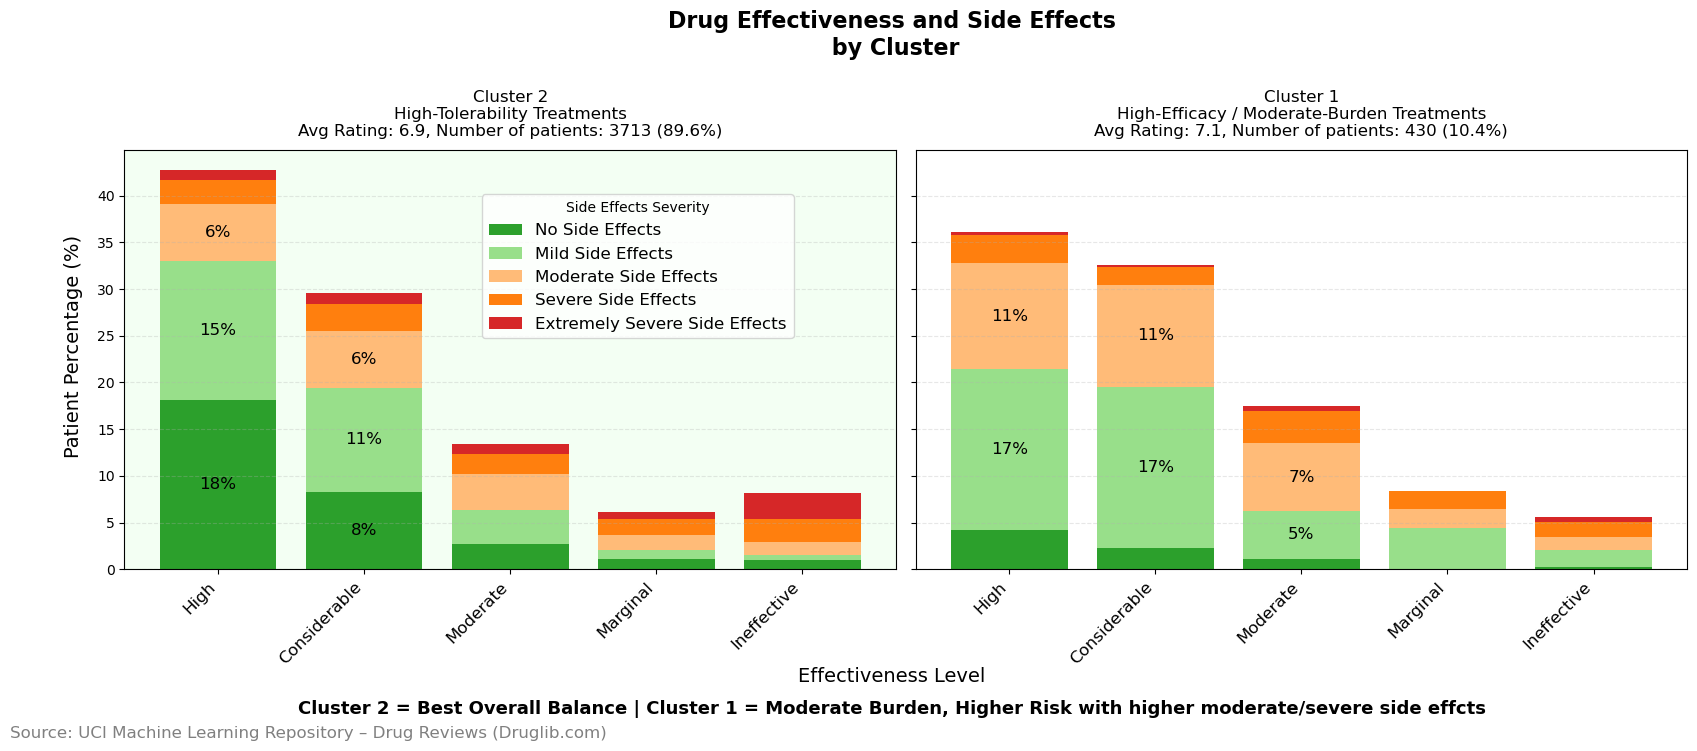

In [25]:
# ==============================
# 1. Orders & Labels
# ==============================

effectiveness_order_2 = ["High", "Considerable", "Moderate", "Marginal", "Ineffective"]
cluster_order_2 = [2, 1]

side_effects_order_2 = [
    "No Side Effects",
    "Mild Side Effects",
    "Moderate Side Effects",
    "Severe Side Effects",
    "Extremely Severe Side Effects"
]

colors = {
    "No Side Effects": "#2ca02c",            # dark green
    "Mild Side Effects": "#98df8a",          # light green
    "Moderate Side Effects": "#ffbb78",      # light orange
    "Severe Side Effects": "#ff7f0e",        # orange
    "Extremely Severe Side Effects": "#d62728"  # red
}

cluster_labels_2 = {
    1: "High-Efficacy / Moderate-Burden Treatments",
    2: "High-Tolerability Treatments"
}

# ==============================
# 2. Prepare Data (Pivot)
# ==============================

pivot_df_2 = percentage_table_2.pivot_table(
    index=['cluster', 'effectiveness_short'],
    columns='side_effects',
    values='percentage',
    fill_value=0
).reset_index()

# ==============================
# 3. Create Figure
# ==============================

fig_2, axes_2 = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

# ==============================
# 4. Plot Each Cluster
# ==============================

for ax, cluster_id in zip(axes_2, cluster_order_2):
    
    data = pivot_df_2[pivot_df_2['cluster'] == cluster_id]
    data = data.set_index('effectiveness_short').reindex(effectiveness_order_2)
    
    bottom = pd.Series([0]*len(effectiveness_order_2), index=effectiveness_order_2)
    
    for side in side_effects_order_2:
        
        values = data[side]
        
        ax.bar(
            effectiveness_order_2,
            values,
            bottom=bottom,
            label=side,
            color=colors[side]
        )
        
        # Add labels (>5%)
        for i, v in enumerate(values):
            if v > 5:
                ax.text(
                    i,
                    bottom.iloc[i] + v/2,
                    f"{v:.0f}%",
                    ha='center',
                    va='center',
                    fontsize=12
                )
        
        bottom += values
    
    # Subplot Title
    rating = avg_ratings_2.get(cluster_id, None)
    rating_text = f"{rating:.1f}" if isinstance(rating, (int, float)) else "N/A"

    num_patients = n_patients.get(cluster_id, None)
    n_text = f"{num_patients}" if isinstance(num_patients, (int, float)) else "N/A"

    p = per_patients.get(cluster_id, None)
    p_text = f"{p}" if isinstance(p, (int, float)) else "N/A"
    
    ax.set_title(
        f"Cluster {cluster_id}\n{cluster_labels_2[cluster_id]}\nAvg Rating: {rating_text}, Number of patients: {n_text} ({p_text}%)",
        fontsize=12,
        pad=10
    )
    
    # Grid for readability
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Rotate x-axis labels
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)

# ==============================
# 5. Global Titles & Labels
# ==============================

fig_2.suptitle(
    "Drug Effectiveness and Side Effects\n by Cluster",
    fontsize=16,
    fontweight='bold',
    y=0.92
)

fig_2.text(0.5, 0.08, "Effectiveness Level", ha='center', fontsize=14)
fig_2.text(0.04, 0.5, "Patient Percentage (%)", va='center', rotation='vertical', fontsize=14)

axes_2[0].set_facecolor("#f3fff3")  # light green tint

fig_2.text(0.5, 0.04,
         "Cluster 2 = Best Overall Balance | Cluster 1 = Moderate Burden, Higher Risk with higher moderate/severe side effcts",
         ha='center', fontsize=13, fontweight='bold')
# ==============================
# 6. Legend (ordered & clean)
# ==============================

handles, labels = axes_2[0].get_legend_handles_labels()

fig_2.legend(
    handles,
    labels,
    title="Side Effects Severity",
    loc='upper right',
    fontsize=12,
    bbox_to_anchor=(0.45, 0.7)
)

# ==============================
# 7. Data Source (Professional Touch)
# ==============================

fig_2.text(
    0.01, 0.01,
    "Source: UCI Machine Learning Repository – Drug Reviews (Druglib.com)",
    fontsize=12,
    color="gray"
)

plt.tight_layout(rect=[0.05, 0.08, 0.95, 0.92])

# ==============================
# 8. Save chart
# ==============================
plt.savefig("images/cluster_chart_2.png", dpi=300, bbox_inches='tight', facecolor='white')

plt.show()

The dataset reveals two primary patient profiles. Cluster 2 represents the vast majority of the population (89.6%) and achieves a "Best Overall Balance" with high effectiveness and high tolerability. Cluster 1 (10.4%) identifies a smaller group of "Resilient Responders" who experience slightly higher average efficacy (average rating: 7.1) but at the cost of a significantly higher side-effect burden.

**Cluster 2: High-Tolerability (The Optimal Group)**

- Population: 3,713 patients (89.6%)
- Average Rating: 6.9/10

- Key Characteristics:
    - Low Burden: The "High" effectiveness category is dominated by patients experiencing No Side Effects (18%) or Mild Side Effects (15%).
    - Safety Profile: Shows the lowest incidence of "Severe" or "Extremely Severe" reactions across all effectiveness levels.

This is the ideal therapeutic outcome where the drug provides significant benefit with minimal physiological interference.

**Cluster 1: High-Efficacy / Moderate-Burden (The Sensitive Group)**

- Population: 430 patients (10.4%)
- Average Rating: 7.1/10
- Key Characteristics:
    - Increased Potency: This group reports a slightly higher average effectiveness than Cluster 2.
    - Notable Side Effects: Even at "High" effectiveness, 28% of patients experience Mild (17%) or Moderate (11%) side effects.
    - Risk Profile: Unlike Cluster 2, this group lacks a significant "No Side Effects" population in the high-performance tier.

These patients experience a high therapeutic "signal" but are more physiologically sensitive to the drug's presence, requiring more active side-effect management.

**Effectiveness vs. Side Effect Trends**

- Direct Correlation: In both clusters, higher effectiveness levels generally correlate with a higher volume of reported side effects, though the intensity varies by cluster.
- Diminishing Returns: As effectiveness drops to "Marginal" or "Ineffective," the patient count shrinks, and the side-effect profile becomes more erratic, particularly in Cluster 2.
- The "Success" Peak: The vast majority of the data is concentrated in the "High" and "Considerable" effectiveness categories, suggesting the drug is broadly successful for the tested population.
-  For the patients who find the drug most effective in Cluster 2, over 75% of them (33% out of the 43%) are having a very positive experience with little to no physical "cost". Only about 10% of patients in that high-efficacy category are dealing with moderate to severe side effects. This is exactly why Cluster 2 could be labeled as the "Best Overall Balance". With the highest effectiveness comes the lowest volume of significant side effects.
- The medication is highly effective for nearly 90% of patients with a very clean safety profile (Cluster 2). However, clinicians should monitor the 10% of patients (Cluster 1) who, while benefiting slightly more from the drug, will likely require support for mild-to-moderate side effects.